# Módulo 3: Limpieza y transformación de datos

## Selección de características:  Logistic Regression

#### Objetivo
* Conceptos
    * Explicar someramente qué es una regresión logística.
    * Entender la implicación de los coeficientes de los predictores.
    * Seleccionar con base en una serie de modelos dummy las variables más importantes.


#### Actividad 1 guiada:
* Leer base: `actividad2a_7_0.csv`
* Crear un ejemplo en el cual observemos la diferencia de variables con coeficientes altos vs variables con coeficientes bajos.
* Crear un método de selección de variables en función de distintas iteraciones de un modelo de regresión logística.

 
#### Actividad 2 autónoma:
* Tomar el dataset `actividad2a_7_0.csv` y hacer una selección de features importantes a través de:
    * El método de varianza.
    * El método de correlaciones.
    * El método de regresión logística.

* Toma los resultados y:
    * Selecciona un set de variables por método tal que los sets sean competitivos (similares en performance tratando de maximizarlo). 
    * Explica por qué seleccionaste cada uno de los sets.

* Una vez hecho eso responder:
    * ¿Por qué los primeros dos métodos (correlación y varianza) seleccionan muchas más variables que el método de coeficientes?
    * Al ver el performance de cada uno, ¿cuál método utilizarías para elegir variables? ¿por qué?
    * ¿Qué podemos esperar del método de varianza cuando tenemos variables llenas de ruido (casi aleatorias)?
    * Busca la definición de "correlación espuria" y explica cómo esto podría afectar al método de selección por correlaciones.
    * ¿Por qué el método de selección con base en coeficientes de un modelo sencillo parece ser mejor que los demás?
    * ¿Qué desventajas tiene usar el método de coeficientes con base en único modelo (a diferencia de múltiples modelos como lo hecho en la actividad 1)?
    * ¿Cuál de los 3 métodos es el mejor?
    

Una regresión logística tiene la forma final de una logit function:

$$\hat{y} = \frac{1}{1 + e^-({\beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_nx_n})}$$

donde $\beta$ son coeficientes estimados de un proceso de minimización (no cubierto en este curso) y $x_n$ son las variables predictoras. 

Dicha función tiene un output limitado entre 0 y 1, lo cual podemos interpretar como la probabilidad de éxito (o de obtener cierta clase, $P(Y = 1)$ de la siguiente forma:

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.datasets import make_classification
import warnings
import os

warnings.filterwarnings("ignore")

%matplotlib inline
plt.style.use('ggplot')

seed = 28
path = '.'

In [92]:
# Vector de x en un rango cualquiera.


# Ese mismo vector pasado por la función sigmoide.


El reto entonces es estimar esos coeficientes no para modelar (al menos no en este curso), sino **para observar cuáles son las variables más relevantes.**

Supongamos que tenemos el siguiente problema:
* $y$: Precio de un inmueble.
* $x_0$: Edad del propietario.
* $x_1$: Puntos del actual primer lugar del campeonato de La LigaMX. 
* $x_2$: Metros cuadrados del inmueble.

¿Qué se observa en una ecuación como la siguiente? 

$$y = 0x_0 + 0x_1 + 10x_2$$

¿Tienen relevancia alguna las variables $x_0$ o $x_1$? No, están siendo multiplicadas por cero. La ecuación anterior se puede rescribir como: 

$$y = 10x_2$$


Dejando en evidencia que si el algoritmo, después de su proceso de optimización "deja de lado" las primeras dos variables, desde un principio pudimos habernos deshecho de ellas y tener un algoritmo "más limpio", con menor riesgo operativo y con una mejor preselección. 

El objetivo de esta clase es crear una serie de modelos con diferentes características entre si que nos permitan seleccionar coeficientes y con ello, una serie de variables más importantes.

In [93]:
file_name = 'actividad2a_7_0.csv'

df = pd.read_csv(os.path.join(path, file_name), index_col=0)

In [94]:
# Separando sets
predictors = [c for c in df if c != 'y']

x_train, x_test, y_train, y_test = train_test_split(df[predictors],
                                                    df['y'],
                                                    random_state=seed)


In [95]:
model = LogisticRegression(random_state=seed)
model.fit(x_train, y_train)

LogisticRegression(random_state=28)

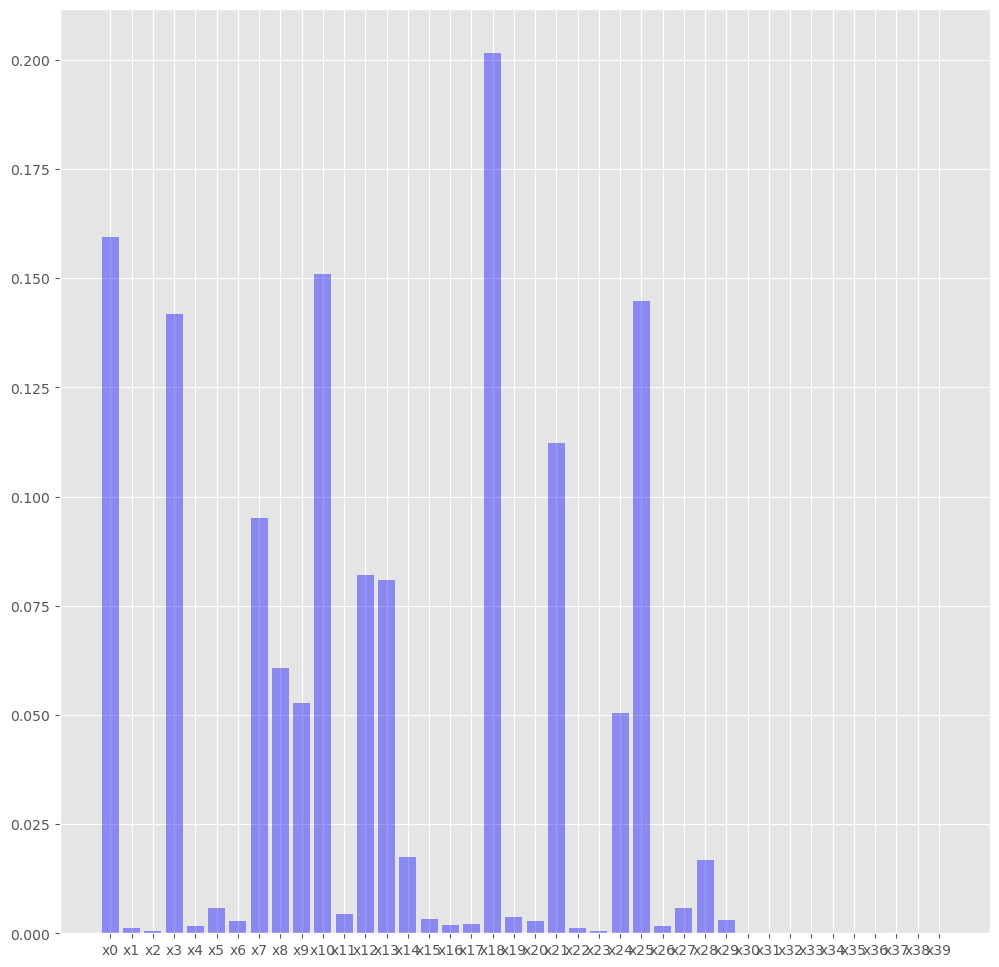

In [96]:
# Creando modelo
index = list(range(len(predictors)))

fig, ax = plt.subplots(figsize=(12,12))
ax.bar(index, np.abs(model.coef_[0]), color='blue', alpha=0.4)
ax.set_xticks(index)
ax.set_xticklabels(predictors)

fig.show()

En este momento no vamos a estimar probabilidades, vamos a analizar las variables más importantes, es decir, los coeficientes.

In [97]:
# Ubicando todo en un arreglo unidimensional


Evidentemente hay variables que:
* Son irrelevantes.
* Tienen influencia parecida, aunque no necesariamente provean de la misma información.
* Son muy importantes.


Pudeira pensarse en poner un threshold para identificar a las más importantes y listo, propongamos algo ligeramente diferente.

### KFold

Esta estrategia nos permite dividir en $k$ grupos nuestro dataset de entrenamiento de tal manera que podamos tener un "test set" móvil y así tener mayor confianza en nuestra métrica de performance.


El código de la siguiente celda pertenece a:

https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html


<Axes: title={'center': 'KFold'}, xlabel='Sample index', ylabel='CV iteration'>

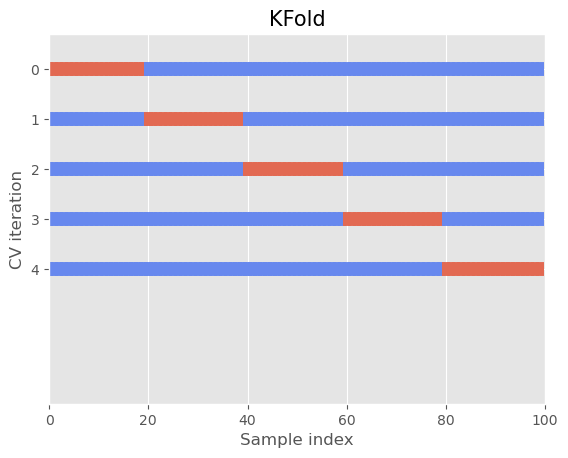

In [98]:
def plot_cv_indices(cv, X, y, group, ax, n_splits, lw=10):
    """Create a sample plot for indices of a cross-validation object."""

    # Generate the training/testing visualizations for each CV split
    for ii, (tr, tt) in enumerate(cv.split(X=X, y=y, groups=group)):
        # Fill in indices with the training/test groups
        indices = np.array([np.nan] * len(X))
        indices[tt] = 1
        indices[tr] = 0

        # Visualize the results
        ax.scatter(range(len(indices)), [ii + .5] * len(indices),
                   c=indices, marker='_', lw=lw, cmap=cmap_cv,
                   vmin=-.2, vmax=1.2)

#     # Plot the data classes and groups at the end
#     ax.scatter(range(len(X)), [ii + 1.5] * len(X),
#                c=y, marker='_', lw=lw, cmap=cmap_data)

#     ax.scatter(range(len(X)), [ii + 2.5] * len(X),
#                c=group, marker='_', lw=lw, cmap=cmap_data)

#     Formatting
    yticklabels = list(range(n_splits)) #+ ['class', 'group']
    ax.set(yticks=np.arange(n_splits) + .5, yticklabels=yticklabels,
           xlabel='Sample index', ylabel="CV iteration",
           ylim=[n_splits+2.2, -.2], xlim=[0, 100])
    ax.set_title('{}'.format(type(cv).__name__), fontsize=15)
    return ax

n_points = 100
cmap_data = plt.cm.Paired
cmap_cv = plt.cm.coolwarm
n_splits = 4
X = np.random.randn(100, 10)

percentiles_classes = [.1, .3, .6]
y = np.hstack([[ii] * int(100 * perc)
               for ii, perc in enumerate(percentiles_classes)])

# Evenly spaced groups repeated once
groups = np.hstack([[ii] * 10 for ii in range(10)])

n_splits = 5
fig, ax = plt.subplots()
cv = KFold(n_splits)
plot_cv_indices(cv, X, y, groups, ax, n_splits)

#### StratifiedKFold

Es una variante de `KFold` en la cual se hace una repartición "justa" del response en cuestión, es decir, se _estratifica_ la variable de respuesta para que en cada _fold_ se conserve la proporción de la misma. 

### Retomando la clase: 

Usaremos entonces una estrategia de Kfold estratificada combinada con una regresión logística default para determinar la mejor cantidad de variables, esto sobre todo será útil a la hora de trabajar con desbalances en clases. 

In [99]:
kfold = StratifiedKFold(n_splits=7, random_state=seed, shuffle=True)

Iteremos sobre nuestro frame generando set de _train_ y set de _test_ respecto de nuestros datos. 

In [100]:
index = 0
coefs = {}

for train_index, test_index in kfold.split(df[predictors], df['y']):
    train_df = df.loc[train_index]
    test_df = df.loc[test_index]

    model = LogisticRegression(random_state=seed)
    model.fit(train_df[predictors], train_df['y'])

    coefs[index] = dict(zip(predictors, model.coef_[0]))

    index += 1

¿Qué pasó con nuestros coeficientes en todo este proceso? 

<Axes: >

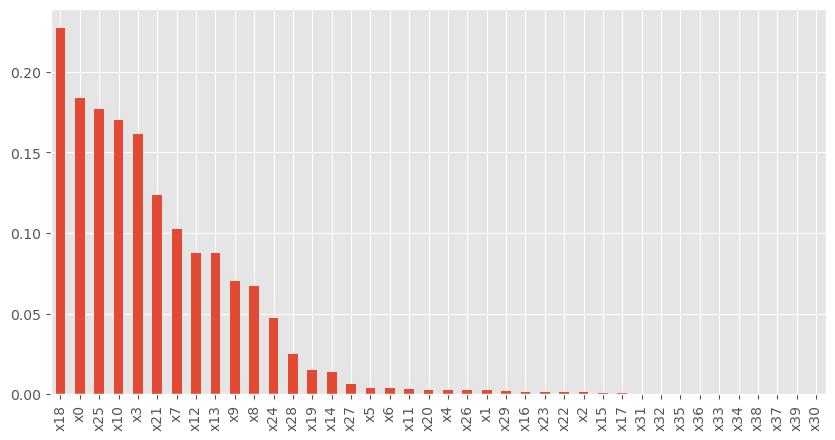

In [101]:
coefs = pd.DataFrame(coefs).loc[predictors]
abs_coefs = coefs.abs()
ordered_means = abs_coefs.mean(axis=1).sort_values(ascending=False)
ordered_means.plot(kind='bar', figsize=(10,5))

Tenemos distintas iteraciones de nuestros coeficientes, ¿cómo concluimos algo entonces? 

Tomaremos aquí un modelo entrenado con las primeros 5 variables, otro con las últimas 5 y un último con todas y veamos las diferencias.

In [102]:
# Las mejores 5
top = ordered_means.head(5).index.tolist()

# Las últimas 5
last = ordered_means.tail(5).index.tolist()

In [103]:
# Generando modelos
top_model = LogisticRegression(random_state=seed)
tail_model = LogisticRegression(random_state=seed)
base_model = LogisticRegression(random_state=seed)

top_model.fit(x_train[top], y_train)
tail_model.fit(x_train[last], y_train)
base_model.fit(x_train[predictors], y_train)

LogisticRegression(random_state=28)

In [104]:
# Estimando scores
top_scores = top_model.predict_proba(x_test[top])[:,1]
tail_scores = tail_model.predict_proba(x_test[last])[:,1]
base_scores = base_model.predict_proba(x_test[predictors])[:,1]


In [105]:
# Midiendo el performance
top_auc = roc_auc_score(y_score=top_scores, y_true=y_test)
tail_auc = roc_auc_score(y_score=tail_scores, y_true=y_test)
base_auc = roc_auc_score(y_score=base_scores, y_true=y_test)

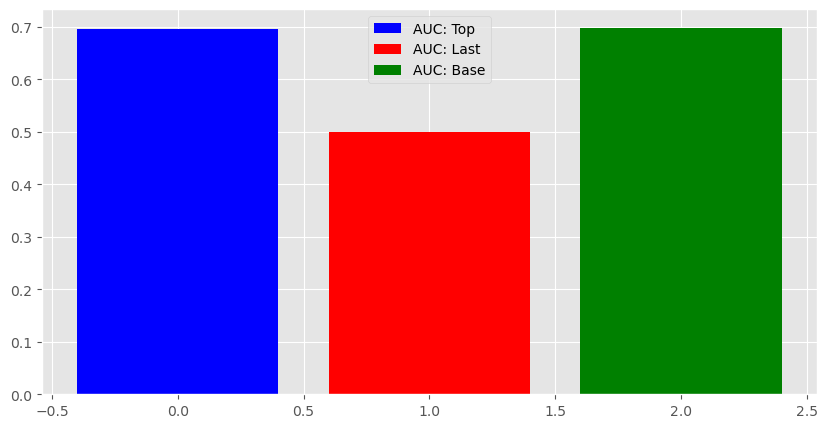

In [106]:
fig, ax =plt.subplots(figsize=(10,5))
ax.bar(0, top_auc, color='blue', label='AUC: Top')
ax.bar(1, tail_auc, color='red', label='AUC: Last')
ax.bar(2, base_auc, color='green', label='AUC: Base')

ax.legend()

##### ¿Cómo podemos estar seguros de que las seleccionadas son efecto mejores que las que se dejan fuera? 

Lo comprobamos directamente con la práctica pero, ¿qué nos dice la comparación de la variable con nuestro objetivo? 

Salvo una de las variables, todas las del lado izquierdo muestran una separación buena a partir de cierto punto. 

Las del lado derecho son erráticos, no parece que podamos hacer un corte o poner coeficientes tales que nos ayuden a crear una frontera óptima. 

#### Cierre de actividad

